Plot aux

In [217]:
import matplotlib.colors as mcolors

def darken_color(color, factor=0.7):
    r, g, b = mcolors.to_rgb(color)
    return (r * factor, g * factor, b * factor)

marker_map = {
    "ProtoGain": "*",
    "Tissue Mean": "+",
    "MissForest": "#"
}

# Holdout cross-validation

In [218]:
import re
import math
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from scipy.stats import gaussian_kde

In [219]:
observed_entry = 1
missing_entry = 0
artificial_missing_entry = 0

In [220]:
tissue_mean_dir = Path("../../experiments/benchmark/PXD030304_no_control_multi_peptide_50pct_tissue/official/tissue_mean/holdout/benchmark_2026-04-17_09:38:58/tissue-mean/")
mf_dir = Path("../../experiments/benchmark/PXD030304_no_control_multi_peptide_50pct_tissue/official/missforest/holdout/benchmark_2026-04-17_09:57:37/missForest")
protogain_dir = Path("../../experiments/benchmark/PXD030304_no_control_multi_peptide_50pct_tissue/official/protogain/holdout/benchmark_2026-04-17_10:06:14/protogain")

In [221]:
rows = []

In [222]:
# todo está aldrabado para ir buscar o tissue para o missforest
predictions_aux_path = Path("../../experiments/benchmark/PXD030304_no_control_multi_peptide_50pct_tissue/official/protogain/holdout/benchmark_2026-04-17_10:06:14/protogain/miss_10/run_001_seed_42_2026-04-17_10:06:14/predictions/predictions.csv")
predictions_aux = pd.read_csv(predictions_aux_path)

sample_tissues = predictions_aux.groupby("sample_id")["group_id"].unique()
sample_tissues

sample_id
PXD030304-Sample-1      [Haematopoietic and Lymphoid]
PXD030304-Sample-10                          [Kidney]
PXD030304-Sample-100    [Haematopoietic and Lymphoid]
PXD030304-Sample-101                       [Pancreas]
PXD030304-Sample-102                        [Thyroid]
                                    ...              
PXD030304-Sample-95                        [Pancreas]
PXD030304-Sample-96                 [Large Intestine]
PXD030304-Sample-97          [Central Nervous System]
PXD030304-Sample-98                          [Cervix]
PXD030304-Sample-99                 [Large Intestine]
Name: group_id, Length: 949, dtype: object

In [223]:
all_unique = sample_tissues.explode().unique()

In [224]:
for miss_dir in mf_dir.iterdir():
    match = re.search(r"miss_(\d+)", miss_dir.stem)
    miss_level = int(match.group(1)) if match else None
    for run_dir in miss_dir.iterdir():
        match = re.search(r"run_(\d+)", run_dir.stem)
        run_id = int(match.group(1)) if match else None

        evaluation_dir = run_dir / "evaluation/holdout"
        true_matrix = pd.read_csv(evaluation_dir / "true_matrix.csv", index_col=0)
        pred_matrix = pd.read_csv(evaluation_dir / "pred_matrix.csv", index_col=0)
        artificial_missing_mask_matrix = pd.read_csv(evaluation_dir / "artificial_missing_mask.csv", index_col=0)

        mapping = sample_tissues.explode().reset_index()
        mapping.columns = ["sample_id", "tissue"]
        tissues = mapping["tissue"].unique()

        for tissue in tissues:
            sample_ids = mapping.loc[mapping["tissue"] == tissue, "sample_id"]
            num_samples = len(sample_ids)
            
            true_subset = true_matrix.loc[true_matrix.index.intersection(sample_ids)]
            mask_subset = artificial_missing_mask_matrix.loc[true_subset.index]
            true_values = true_subset[~mask_subset].stack()

            predicted_subset = pred_matrix.loc[pred_matrix.index.intersection(sample_ids)]
            mask_subset = artificial_missing_mask_matrix.loc[predicted_subset.index]
            predicted_values = predicted_subset[~mask_subset].stack()

            r, _ = pearsonr(true_values, predicted_values)
            # print(f"  Pearson r: {r:.4f}")

            # Compute RMSE error per tissue
            tissue_model_rmse = np.sqrt(np.mean((true_values - predicted_values) ** 2))
            # print(f"  MissForest RMSE: {tissue_model_rmse:.4f}")

            rows.append(
                { 
                    "Tissue": tissue,
                    "Number of samples": num_samples, 
                    "Pearson r": r,
                    "RMSE": tissue_model_rmse,
                    "Model": "MissForest"
                }
            )


In [225]:
for miss_dir in protogain_dir.iterdir():
    match = re.search(r"miss_(\d+)", miss_dir.stem)
    miss_level = int(match.group(1)) if match else None
    print(f"=== Missing level {miss_level} ===")
    for run_dir in miss_dir.iterdir():
        if not run_dir.is_dir():
            continue

        match = re.search(r"run_(\d+)", run_dir.stem)
        run_number = int(match.group(1)) if match else None

        # Imputation performance per tissue
        predictions = pd.read_csv(
            run_dir / f"predictions/predictions.csv"
        )

        tissues = predictions["group_id"].unique()

        for tissue in tissues:
            print("Tissue", tissue)

            # Filter for current tissue + conditions
            tissue_entries = predictions[
                (predictions["group_id"] == tissue) &
                (predictions["artificial_missing_mask"] == artificial_missing_entry) &
                (predictions["observed_mask"] == observed_entry)
            ]

            tissue_samples = tissue_entries.groupby("sample_id")
            num_samples = len(tissue_samples)

            true_values = tissue_entries["true_value"].to_numpy(dtype=float)
            predicted_values = tissue_entries["predicted_value"].to_numpy(dtype=float)

            r, _ = pearsonr(true_values, predicted_values)
            print(f"  Pearson r: {r:.4f}")

            # Compute RMSE error per tissue
            tissue_model_rmse = np.sqrt(np.mean((true_values - predicted_values) ** 2))
            print(f"  ProtoGain RMSE: {tissue_model_rmse:.4f}")

            rows.append(
                { 
                    "Tissue": tissue,
                    "Number of samples": num_samples, 
                    "Pearson r": r,
                    "RMSE": tissue_model_rmse,
                    "Model": "ProtoGain"
                }
            )

# plt.figure(figsize=(6, 6))
# sns.scatterplot(
#     x=true_values,
#     y=predicted_values,
#     alpha=0.5,
#     s=30,
#     edgecolor="none"
# )

# min_val = min(true_values.min(), predicted_values.min())
# max_val = max(true_values.max(), predicted_values.max())
# plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", linewidth=1)

# ax = plt.gca()
# ax.spines["top"].set_visible(False)
# ax.spines["right"].set_visible(False)

# plt.xlabel("Observed value")
# plt.ylabel("Predicted value")
# plt.axis("equal")
# plt.grid(True, linestyle="--", alpha=0.4, zorder=0)

=== Missing level 10 ===
Tissue Haematopoietic and Lymphoid
  Pearson r: 0.9035
  ProtoGain RMSE: 0.2679
Tissue Kidney
  Pearson r: 0.9174
  ProtoGain RMSE: 0.2520
Tissue Pancreas
  Pearson r: 0.9056
  ProtoGain RMSE: 0.2689
Tissue Thyroid
  Pearson r: 0.9175
  ProtoGain RMSE: 0.2545
Tissue Lung
  Pearson r: 0.9106
  ProtoGain RMSE: 0.2604
Tissue Skin
  Pearson r: 0.9188
  ProtoGain RMSE: 0.2496
Tissue Peripheral Nervous System
  Pearson r: 0.9167
  ProtoGain RMSE: 0.2515
Tissue Bone
  Pearson r: 0.9129
  ProtoGain RMSE: 0.2534
Tissue Large Intestine
  Pearson r: 0.9167
  ProtoGain RMSE: 0.2536
Tissue Esophagus
  Pearson r: 0.9133
  ProtoGain RMSE: 0.2574
Tissue Endometrium
  Pearson r: 0.9071
  ProtoGain RMSE: 0.2608
Tissue Breast
  Pearson r: 0.9062
  ProtoGain RMSE: 0.2661
Tissue Cervix
  Pearson r: 0.9192
  ProtoGain RMSE: 0.2482
Tissue Liver
  Pearson r: 0.9104
  ProtoGain RMSE: 0.2581
Tissue Ovary
  Pearson r: 0.9071
  ProtoGain RMSE: 0.2643
Tissue Stomach
  Pearson r: 0.9078
  P

In [226]:
for miss_dir in tissue_mean_dir.iterdir():
    match = re.search(r"miss_(\d+)", miss_dir.stem)
    miss_level = int(match.group(1)) if match else None
    print(f"=== Missing level {miss_level} ===")
    for run_dir in miss_dir.iterdir():
        if not run_dir.is_dir():
            continue

        # Imputation performance per tissue
        predictions = pd.read_csv(
            run_dir / f"predictions/predictions.csv"
        )

        tissues = predictions["group_id"].unique()

        for tissue in tissues:
            print("Tissue", tissue)

            # Filter for current tissue + conditions
            tissue_entries = predictions[
                (predictions["group_id"] == tissue) &
                (predictions["artificial_missing_mask"] == artificial_missing_entry) &
                (predictions["observed_mask"] == observed_entry)
            ]

            tissue_samples = tissue_entries.groupby("sample_id")
            num_samples = len(tissue_samples)

            true_values = tissue_entries["true_value"].to_numpy(dtype=float)
            predicted_values = tissue_entries["predicted_value"].to_numpy(dtype=float)

        # tissues = predictions["group_id"].unique()

        # # Compute correlation protogain per tissue
        # for tissue in tissues:
        #     # print("Tissue:", tissue)

        #     tissue_predictions = predictions.groupby("group_id").get_group(tissue)
        #     # print("Tissue\n", tissue_predictions)

        #     tissue_entries = tissue_predictions[
        #         (
        #             (tissue_predictions["artificial_missing_mask"] == artificial_missing_entry)
        #             &
        #             (tissue_predictions["observed_mask"] == observed_entry)
        #         )
        #     ]
            
        #     tissue_samples = tissue_predictions.groupby("sample_id")
        #     num_samples = len(tissue_samples)
        #     # print("Number of samples", num_samples)

        #     true_values = tissue_entries["true_value"].to_numpy(dtype=float)
        #     predicted_values = tissue_entries["predicted_value"].to_numpy(dtype=float)

            r, _ = pearsonr(true_values, predicted_values)
            # print(f"  Pearson r: {r:.4f}")

            # Compute RMSE error per tissue
            tissue_model_rmse = np.sqrt(np.mean((true_values - predicted_values) ** 2))
            # print(f"  Model RMSE: {tissue_model_rmse:.4f}")

            rows.append(
                {
                    "Tissue": tissue,
                    "Number of samples": num_samples, 
                    "Pearson r": r,
                    "RMSE": tissue_model_rmse,
                    "Model": "Tissue Mean"
                }
            )

=== Missing level 10 ===
Tissue Haematopoietic and Lymphoid
Tissue Kidney
Tissue Pancreas
Tissue Thyroid
Tissue Lung
Tissue Skin
Tissue Peripheral Nervous System
Tissue Bone
Tissue Large Intestine
Tissue Esophagus
Tissue Endometrium
Tissue Breast
Tissue Cervix
Tissue Liver
Tissue Ovary
Tissue Stomach
Tissue Head and Neck
Tissue Soft Tissue
Tissue Central Nervous System
Tissue Bladder
Tissue Biliary Tract
Tissue Small Intestine
Tissue Placenta
Tissue Prostate
Tissue Testis
Tissue Other tissue
Tissue Adrenal Gland
Tissue Vulva


In [227]:
tissue_performance = pd.DataFrame(rows)
tissue_performance["Model (Marker)"] = tissue_performance["Model"].apply(lambda x: f"{x} ({marker_map[x]})")
print(tissue_performance)

                         Tissue  Number of samples  Pearson r      RMSE  \
0   Haematopoietic and Lymphoid                163   0.881931  0.278094   
1                        Kidney                 32   0.872168  0.283080   
2                      Pancreas                 30   0.865782  0.287169   
3                       Thyroid                 16   0.878408  0.281722   
4                          Lung                187   0.865108  0.291510   
..                          ...                ...        ...       ...   
79                     Prostate                  8   0.883052  0.264778   
80                       Testis                  3   0.886927  0.269255   
81                 Other tissue                  4   0.850077  0.309364   
82                Adrenal Gland                  1   0.860781  0.296649   
83                        Vulva                  3   0.868103  0.281915   

          Model   Model (Marker)  
0    MissForest   MissForest (#)  
1    MissForest   MissForest 

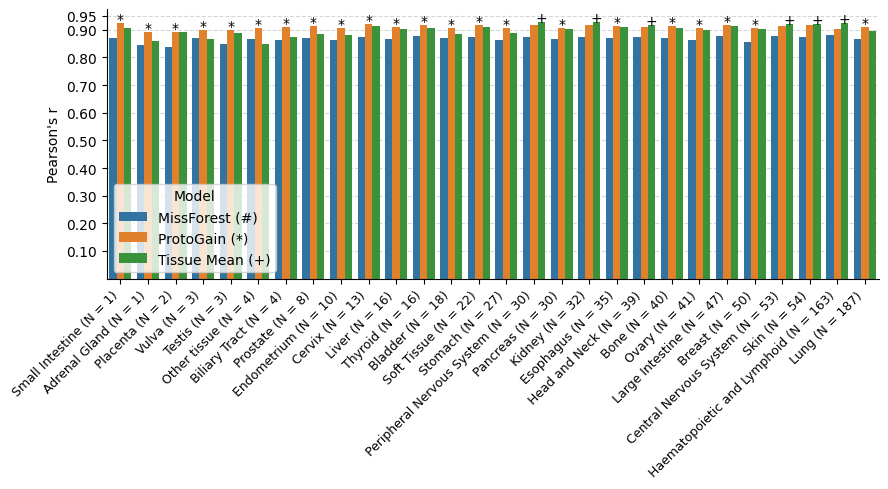

In [228]:
plt.figure(figsize=(9, 5))

# Sort by number of samples using only one model to avoid duplicates
order_df = (
    tissue_performance[tissue_performance["Model"] == "Tissue Mean"]
    .sort_values("Number of samples")
)

tissue_order = order_df["Tissue"].tolist()

x_labels = [
    f"{tissue} (N = {n})"
    for tissue, n in zip(order_df["Tissue"], order_df["Number of samples"])
]

sns.barplot(
    data=tissue_performance,
    x="Tissue",
    y="Pearson r",
    hue="Model (Marker)",
    order=tissue_order,
)

plt.xticks(range(len(x_labels)), x_labels, rotation=45, ha="right", fontsize="9")
# plt.yticks(np.arange(0, 1, step=0.1))
plt.yticks([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95])
plt.ylabel("Pearson's r")
plt.grid(axis="y", linestyle="--", alpha=0.5, zorder=0)
plt.legend(title="Model", loc="lower left")

ax = plt.gca()
ax.set_axisbelow(True)
ax.set_xlabel("")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Highlight model with higher correlation
pivot_df = tissue_performance.pivot(
    index="Tissue", columns="Model", values="Pearson r"
)
best_model_per_tissue = pivot_df.idxmax(axis=1).to_dict()


for container, model_name in zip(ax.containers, tissue_performance["Model"].unique()):
    for bar, tissue in zip(container, tissue_order):
        if best_model_per_tissue[tissue] == model_name:
            original_color = bar.get_facecolor()
            darker_color = darken_color(original_color, factor=0.8)

            marker = marker_map.get(model_name, "*")

            y = bar.get_height()

            ax.text(
                bar.get_x() + bar.get_width() / 2,
                y,
                marker,
                ha="center",
                fontsize=10
            )

            # bar.set_alpha(1.0)
            # bar.set_linewidth(1)
            # bar.set_edgecolor(darker_color)

plt.tight_layout()
plt.savefig(f"./plots/holdout/pearson_by_tissue_miss{miss_level}.png")
plt.show()

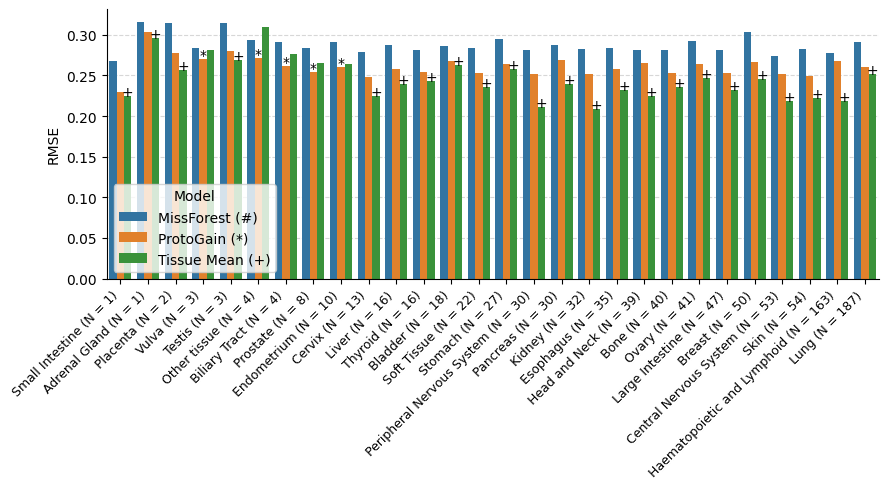

In [229]:
plt.figure(figsize=(9, 5))

# Sort by number of samples using only one model to avoid duplicates
order_df = (
    tissue_performance[tissue_performance["Model"] == "Tissue Mean"]
    .sort_values("Number of samples")
)

tissue_order = order_df["Tissue"].tolist()

x_labels = [
    f"{tissue} (N = {n})"
    for tissue, n in zip(order_df["Tissue"], order_df["Number of samples"])
]

sns.barplot(
    data=tissue_performance,
    x="Tissue",
    y="RMSE",
    hue="Model (Marker)",
    order=tissue_order,
)

plt.xticks(range(len(x_labels)), x_labels, rotation=45, ha="right", fontsize="9")
# plt.yticks(np.arange(0, 1, step=0.1))
plt.ylabel("RMSE")
plt.grid(axis="y", linestyle="--", alpha=0.5, zorder=0)
plt.legend(title="Model", loc="lower left")

ax = plt.gca()
ax.set_axisbelow(True)
ax.set_xlabel("")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Highlight model with higher correlation
pivot_df = tissue_performance.pivot(
    index="Tissue", columns="Model", values="RMSE"
)
best_model_per_tissue = pivot_df.idxmin(axis=1).to_dict()


for container, model_name in zip(ax.containers, tissue_performance["Model"].unique()):
    for bar, tissue in zip(container, tissue_order):
        if best_model_per_tissue[tissue] == model_name:
            original_color = bar.get_facecolor()
            darker_color = darken_color(original_color, factor=0.8)

            marker = marker_map.get(model_name, "*")

            y = bar.get_height()

            ax.text(
                bar.get_x() + bar.get_width() / 2,
                y,
                marker,
                ha="center",
                fontsize=10
            )

            # bar.set_alpha(1.0)
            # bar.set_linewidth(1)
            # bar.set_edgecolor(darker_color)

plt.tight_layout()
plt.savefig(f"./plots/holdout/rmse_by_tissue_miss{miss_level}.png")
plt.show()

## Observed vs. predicted

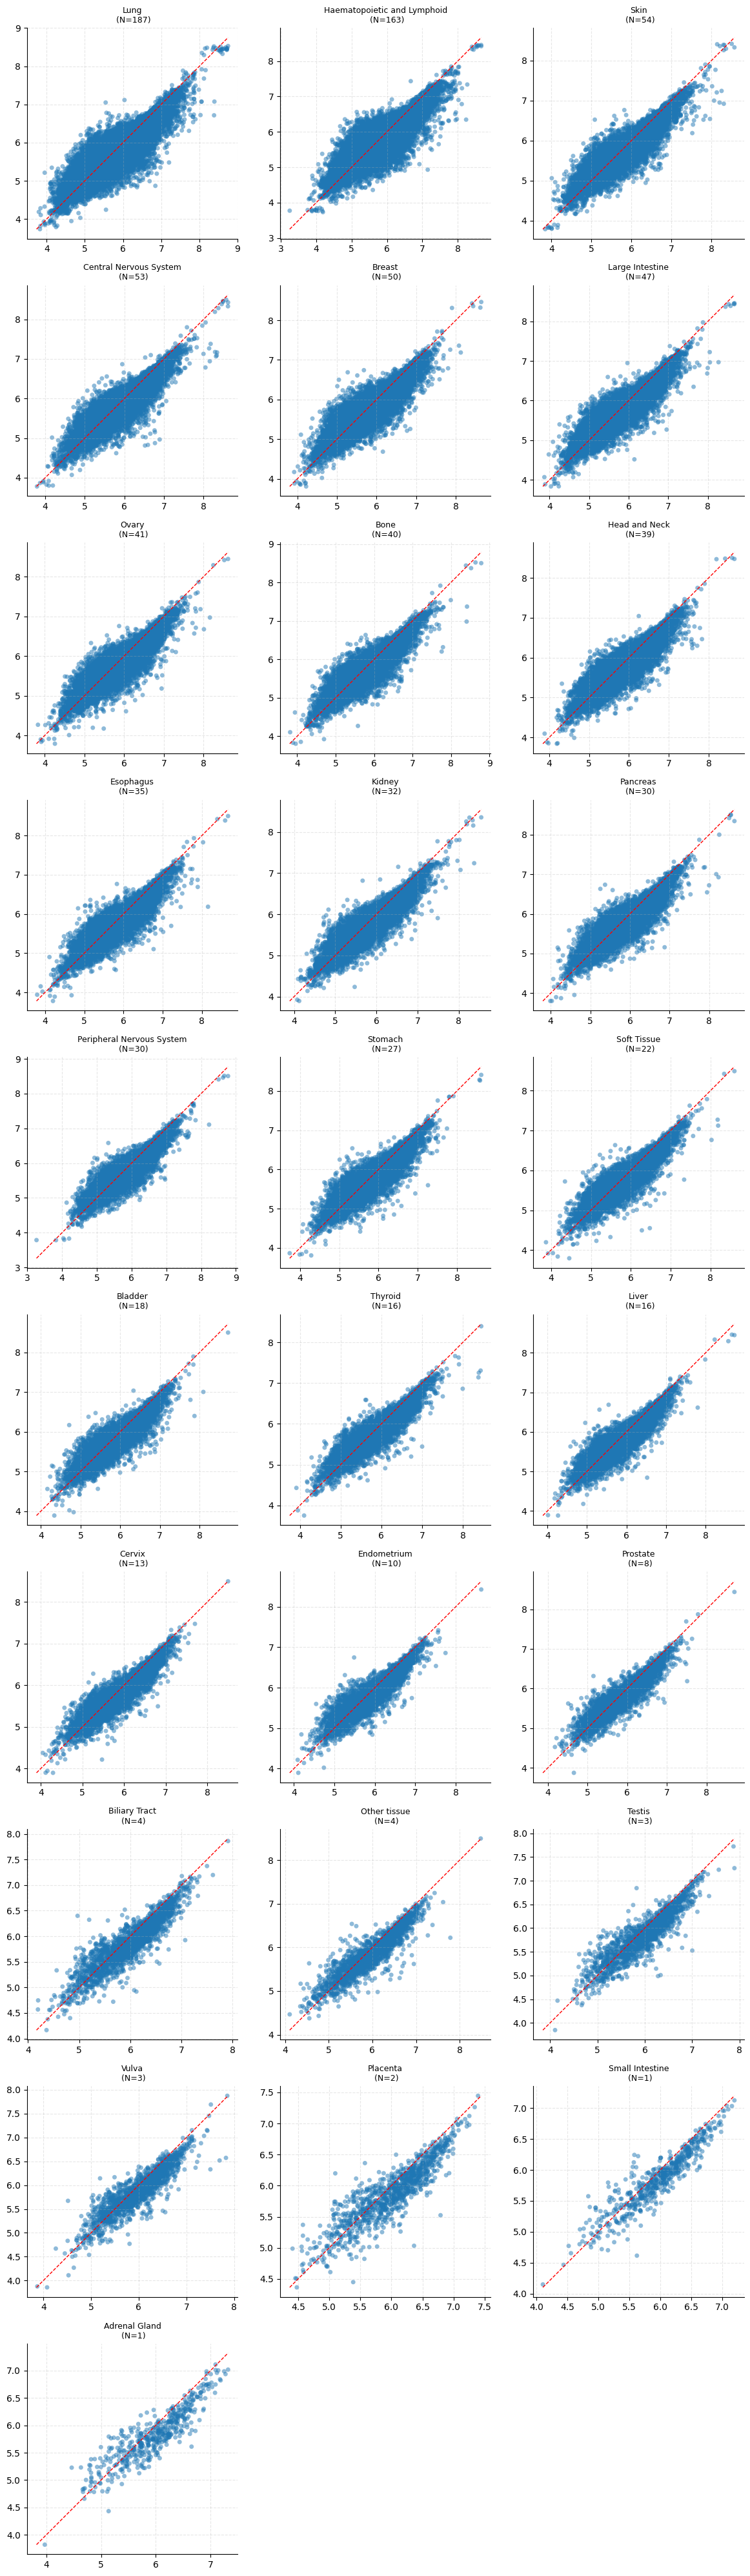

In [230]:
n_cols = 3 # number of plots per row

for miss_dir in protogain_dir.iterdir():
    match = re.search(r"miss_(\d+)", miss_dir.stem)
    miss_level = int(match.group(1)) if match else None
    for run_dir in miss_dir.iterdir():
        if not run_dir.is_dir():
            continue

    match = re.search(r"run_(\d+)", run_dir.stem)
    run_number = int(match.group(1)) if match else None

    all_plots = []

    # Imputation performance per tissue
    predictions = pd.read_csv(
        run_dir / f"predictions/predictions.csv"
    )

    tissues = predictions["group_id"].unique()

    for tissue in tissues:
        # Filter for current tissue + conditions
        tissue_entries = predictions[
            (predictions["group_id"] == tissue) &
            (predictions["artificial_missing_mask"] == artificial_missing_entry) &
            (predictions["observed_mask"] == observed_entry)
        ]

        tissue_samples = tissue_entries.groupby("sample_id")
        num_samples = len(tissue_samples)

        true_values = tissue_entries["true_value"].to_numpy(dtype=float)
        predicted_values = tissue_entries["predicted_value"].to_numpy(dtype=float)

        all_plots.append((tissue, num_samples, true_values, predicted_values))

all_plots = sorted(all_plots, key=lambda x: x[1], reverse=True) # sort descending number of samples

n_plots = len(all_plots)
n_rows = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=n_cols,
    figsize=(4 * n_cols, 4 * n_rows),
    sharex=False,
    sharey=False
)
fig.subplots_adjust(hspace=0.4)

axes = axes.flatten()

for i, (tissue, num_samples, true_values, predicted_values) in enumerate(all_plots):

    ax = axes[i]

    sns.scatterplot(
        x=true_values,
        y=predicted_values,
        alpha=0.5,
        s=25,
        edgecolor="none",
        ax=ax
    )

    min_val = min(true_values.min(), predicted_values.min())
    max_val = max(true_values.max(), predicted_values.max())

    ax.plot([min_val, max_val], [min_val, max_val],
            color="red", linestyle="--", linewidth=1)

    ax.set_title(f"{tissue}\n (N={num_samples})", fontsize=9)

    ax.set_xlabel("")
    ax.set_ylabel("")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.set_aspect("equal", adjustable="box")

for j in range(n_plots, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig(f"./plots/holdout/predicted_vs_observed_protogain_miss{miss_level}.png")

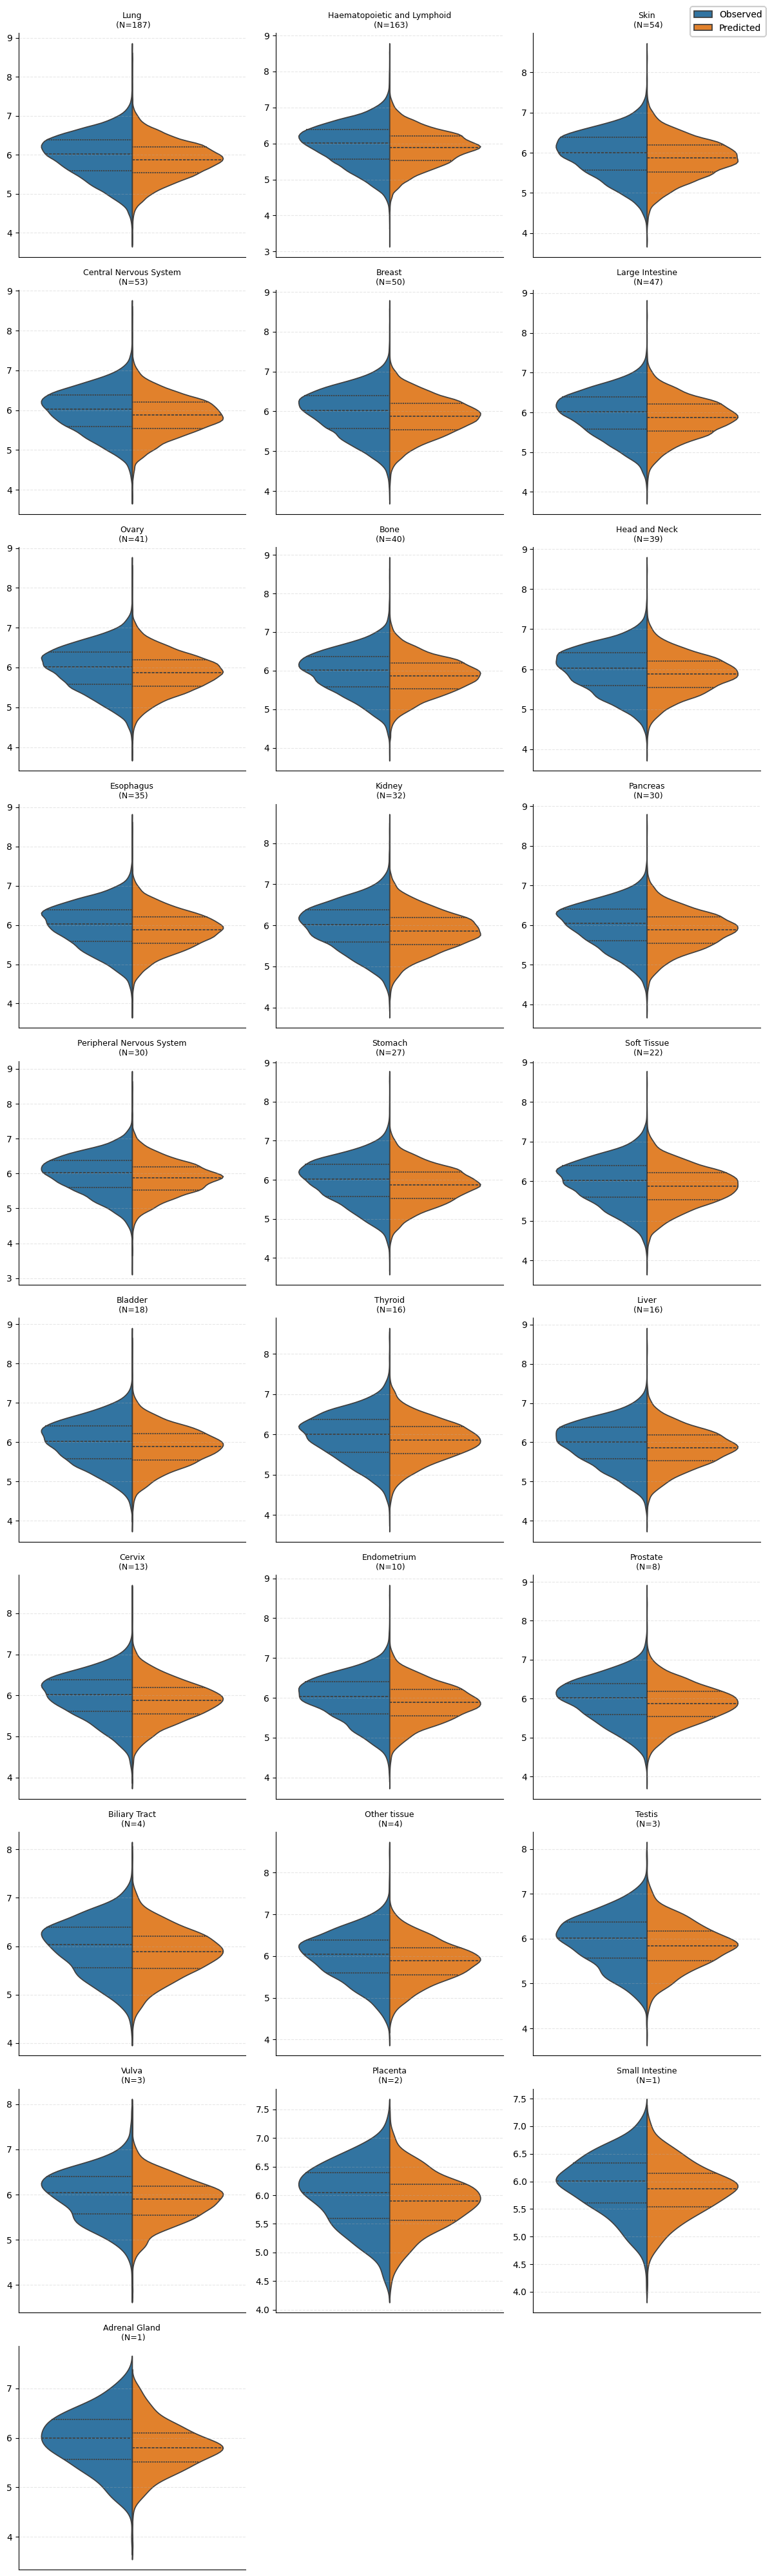

In [231]:
n_cols = 3  # number of plots per row

for miss_dir in protogain_dir.iterdir():
    match = re.search(r"miss_(\d+)", miss_dir.stem)
    miss_level = int(match.group(1)) if match else None
    for run_dir in miss_dir.iterdir():
        if not run_dir.is_dir():
            continue

    match = re.search(r"run_(\d+)", run_dir.stem)
    run_number = int(match.group(1)) if match else None

    all_plots = []

    # Imputation performance per tissue
    predictions = pd.read_csv(
        run_dir / f"predictions/predictions.csv"
    )

    tissues = predictions["group_id"].unique()

    for tissue in tissues:
        # Filter for current tissue + conditions
        tissue_entries = predictions[
            (predictions["group_id"] == tissue) &
            (predictions["artificial_missing_mask"] == artificial_missing_entry) &
            (predictions["observed_mask"] == observed_entry)
        ]

        tissue_samples = tissue_entries.groupby("sample_id")
        num_samples = len(tissue_samples)

        true_values = tissue_entries["true_value"].to_numpy(dtype=float)
        predicted_values = tissue_entries["predicted_value"].to_numpy(dtype=float)

        all_plots.append((tissue, num_samples, true_values, predicted_values))

all_plots = sorted(all_plots, key=lambda x: x[1], reverse=True)  # sort descending number of samples

n_plots = len(all_plots)
n_rows = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=n_cols,
    figsize=(4 * n_cols, 4 * n_rows),
    sharex=False,
    sharey=False
)
fig.subplots_adjust(hspace=0.4)

axes = axes.flatten()

for i, (tissue, num_samples, true_values, predicted_values) in enumerate(all_plots):

    ax = axes[i]

    violin_data = pd.DataFrame({
        "Value": np.concatenate([true_values, predicted_values]),
        "Type": (["Observed"] * len(true_values)) + (["Predicted"] * len(predicted_values))
    })

    violin_data["group"] = "all"

    sns.violinplot(
        data=violin_data,
        x="group",
        y="Value",
        hue="Type",
        split=True,
        inner="quartile",
        ax=ax,
        palette={"Observed": "tab:blue", "Predicted": "tab:orange"}
    )

    ax.set_xticks([])

    ax.set_title(f"{tissue}\n (N={num_samples})", fontsize=9)
    ax.set_xlabel("")
    ax.set_ylabel("")

    ax.legend_.remove()

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, linestyle="--", alpha=0.3, axis="y")

    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="upper right",
        bbox_to_anchor=(1.0, 1.0),
        prop={"weight": "normal"}
    )

for j in range(n_plots, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig(f"./plots/holdout/predicted_vs_observed_distribution_protogain_miss{miss_level}.png")

## Missing level of 20%

In [232]:
tissue_mean_dir = Path("../../experiments/benchmark/PXD030304_no_control_multi_peptide_50pct_tissue/official/tissue_mean/holdout/benchmark_2026-04-17_11:00:10/tissue-mean")
protogain_dir = Path("../../experiments/benchmark/PXD030304_no_control_multi_peptide_50pct_tissue/official/protogain/holdout/benchmark_2026-04-17_10:33:34/protogain")

In [233]:
rows = []

In [234]:
for miss_dir in protogain_dir.iterdir():
    match = re.search(r"miss_(\d+)", miss_dir.stem)
    miss_level = int(match.group(1)) if match else None
    # print(f"=== Missing level {miss_level} ===")
    for run_dir in miss_dir.iterdir():
        if not run_dir.is_dir():
            continue

        match = re.search(r"run_(\d+)", run_dir.stem)
        run_number = int(match.group(1)) if match else None

        # Imputation performance per tissue
        predictions = pd.read_csv(
            run_dir / f"predictions/predictions.csv"
        )

        tissues = predictions["group_id"].unique()

        for tissue in tissues:
            # print("Tissue", tissue)

            # Filter for current tissue + conditions
            tissue_entries = predictions[
                (predictions["group_id"] == tissue) &
                (predictions["artificial_missing_mask"] == artificial_missing_entry) &
                (predictions["observed_mask"] == observed_entry)
            ]

            tissue_samples = tissue_entries.groupby("sample_id")
            num_samples = len(tissue_samples)

            true_values = tissue_entries["true_value"].to_numpy(dtype=float)
            predicted_values = tissue_entries["predicted_value"].to_numpy(dtype=float)

            r, _ = pearsonr(true_values, predicted_values)
            # print(f"  Pearson r: {r:.4f}")

            # Compute RMSE error per tissue
            tissue_model_rmse = np.sqrt(np.mean((true_values - predicted_values) ** 2))
            # print(f"  ProtoGain RMSE: {tissue_model_rmse:.4f}")

            rows.append(
                {
                    "Missing level": miss_level,
                    "Tissue": tissue,
                    "Number of samples": num_samples, 
                    "Pearson r": r,
                    "RMSE": tissue_model_rmse,
                    "Model": "ProtoGain"
                }
            )

In [235]:
for miss_dir in tissue_mean_dir.iterdir():
    match = re.search(r"miss_(\d+)", miss_dir.stem)
    miss_level = int(match.group(1)) if match else None
    print(f"=== Missing level {miss_level} ===")
    for run_dir in miss_dir.iterdir():
        if not run_dir.is_dir():
            continue

        # Imputation performance per tissue
        predictions = pd.read_csv(
            run_dir / f"predictions/predictions.csv"
        )

        tissues = predictions["group_id"].unique()

        # Compute correlation protogain per tissue
        for tissue in tissues:
            # print("Tissue:", tissue)

            tissue_predictions = predictions.groupby("group_id").get_group(tissue)
            # print("Tissue\n", tissue_predictions)

            tissue_entries = tissue_predictions[
                (
                    (tissue_predictions["artificial_missing_mask"] == artificial_missing_entry)
                    &
                    (tissue_predictions["observed_mask"] == observed_entry)
                )
            ]
            
            tissue_samples = tissue_predictions.groupby("sample_id")
            num_samples = len(tissue_samples)
            # print("Number of samples", num_samples)

            true_values = tissue_entries["true_value"].to_numpy(dtype=float)
            predicted_values = tissue_entries["predicted_value"].to_numpy(dtype=float)

            r, _ = pearsonr(true_values, predicted_values)
            # print(f"  Pearson r: {r:.4f}")

            # Compute RMSE error per tissue
            tissue_model_rmse = np.sqrt(np.mean((true_values - predicted_values) ** 2))
            # print(f"  Model RMSE: {tissue_model_rmse:.4f}")

            rows.append(
                {
                    "Tissue": tissue,
                    "Number of samples": num_samples, 
                    "Pearson r": r,
                    "RMSE": tissue_model_rmse,
                    "Model": "Tissue Mean"
                }
            )

=== Missing level 20 ===


In [236]:
tissue_performance = pd.DataFrame(rows)
tissue_performance["Model (Marker)"] = tissue_performance["Model"].apply(lambda x: f"{x} ({marker_map[x]})")
print(tissue_performance)

    Missing level                       Tissue  Number of samples  Pearson r  \
0            20.0  Haematopoietic and Lymphoid                163   0.876058   
1            20.0                       Kidney                 32   0.889500   
2            20.0                     Pancreas                 30   0.877200   
3            20.0                      Thyroid                 16   0.889725   
4            20.0                         Lung                187   0.886449   
5            20.0                         Skin                 54   0.892613   
6            20.0    Peripheral Nervous System                 30   0.883701   
7            20.0                         Bone                 40   0.886375   
8            20.0              Large Intestine                 47   0.890715   
9            20.0                    Esophagus                 35   0.888248   
10           20.0                  Endometrium                 10   0.882523   
11           20.0                       

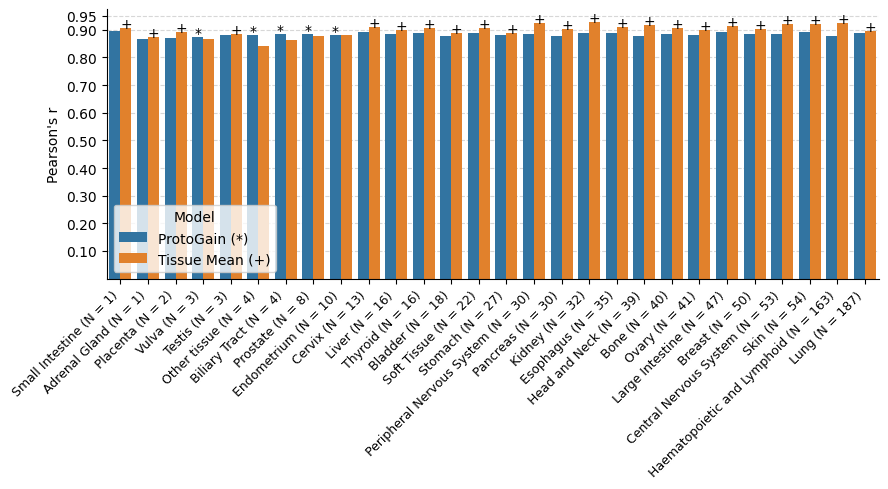

In [237]:
plt.figure(figsize=(9, 5))

# Sort by number of samples using only one model to avoid duplicates
order_df = (
    tissue_performance[tissue_performance["Model"] == "ProtoGain"]
    .sort_values("Number of samples")
)

tissue_order = order_df["Tissue"].tolist()

x_labels = [
    f"{tissue} (N = {n})"
    for tissue, n in zip(order_df["Tissue"], order_df["Number of samples"])
]

sns.barplot(
    data=tissue_performance,
    x="Tissue",
    y="Pearson r",
    hue="Model (Marker)",
    order=tissue_order,
)

plt.xticks(range(len(x_labels)), x_labels, rotation=45, ha="right", fontsize="9")
# plt.yticks(np.arange(0, 1, step=0.1))
plt.yticks([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95])
plt.ylabel("Pearson's r")
plt.grid(axis="y", linestyle="--", alpha=0.5, zorder=0)
plt.legend(title="Model", loc="lower left")

ax = plt.gca()
ax.set_axisbelow(True)
ax.set_xlabel("")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Highlight model with higher correlation
pivot_df = tissue_performance.pivot(
    index="Tissue", columns="Model", values="Pearson r"
)
best_model_per_tissue = pivot_df.idxmax(axis=1).to_dict()


for container, model_name in zip(ax.containers, tissue_performance["Model"].unique()):
    for bar, tissue in zip(container, tissue_order):
        if best_model_per_tissue[tissue] == model_name:
            original_color = bar.get_facecolor()
            darker_color = darken_color(original_color, factor=0.8)

            marker = marker_map.get(model_name, "*")

            y = bar.get_height()

            ax.text(
                bar.get_x() + bar.get_width() / 2,
                y,
                marker,
                ha="center",
                fontsize=10
            )

            # bar.set_alpha(1.0)
            # bar.set_linewidth(1)
            # bar.set_edgecolor(darker_color)

plt.tight_layout()
plt.savefig(f"./plots/holdout/pearson_by_tissue_miss{miss_level}.png")
plt.show()

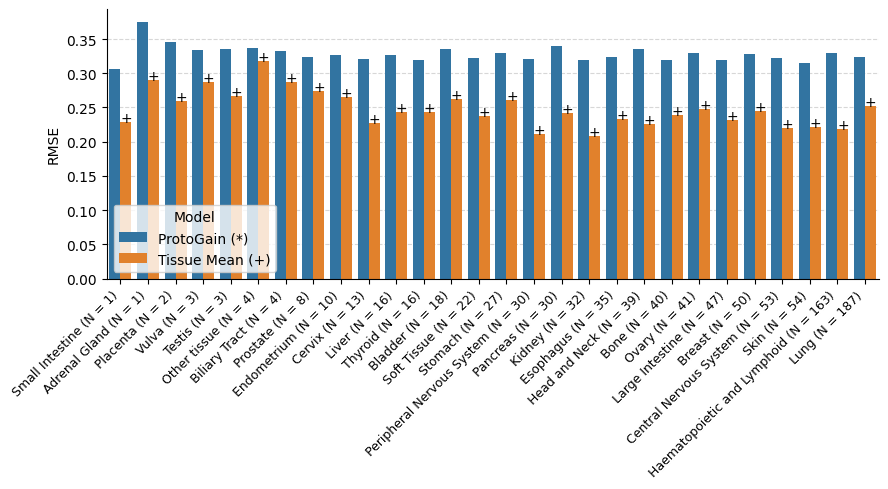

In [238]:
plt.figure(figsize=(9, 5))

# Sort by number of samples using only one model to avoid duplicates
order_df = (
    tissue_performance[tissue_performance["Model"] == "ProtoGain"]
    .sort_values("Number of samples")
)

tissue_order = order_df["Tissue"].tolist()

x_labels = [
    f"{tissue} (N = {n})"
    for tissue, n in zip(order_df["Tissue"], order_df["Number of samples"])
]

sns.barplot(
    data=tissue_performance,
    x="Tissue",
    y="RMSE",
    hue="Model (Marker)",
    order=tissue_order,
)

plt.xticks(range(len(x_labels)), x_labels, rotation=45, ha="right", fontsize="9")
# plt.yticks(np.arange(0, 1, step=0.1))
plt.ylabel("RMSE")
plt.grid(axis="y", linestyle="--", alpha=0.5, zorder=0)
plt.legend(title="Model", loc="lower left")

ax = plt.gca()
ax.set_axisbelow(True)
ax.set_xlabel("")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Highlight model with higher correlation
pivot_df = tissue_performance.pivot(
    index="Tissue", columns="Model", values="RMSE"
)
best_model_per_tissue = pivot_df.idxmin(axis=1).to_dict()


for container, model_name in zip(ax.containers, tissue_performance["Model"].unique()):
    for bar, tissue in zip(container, tissue_order):
        if best_model_per_tissue[tissue] == model_name:
            original_color = bar.get_facecolor()
            darker_color = darken_color(original_color, factor=0.8)

            marker = marker_map.get(model_name, "*")

            y = bar.get_height()

            ax.text(
                bar.get_x() + bar.get_width() / 2,
                y,
                marker,
                ha="center",
                fontsize=10
            )

            # bar.set_alpha(1.0)
            # bar.set_linewidth(1)
            # bar.set_edgecolor(darker_color)

plt.tight_layout()
plt.savefig(f"./plots/holdout/rmse_by_tissue_miss{miss_level}.png")
plt.show()

# Performance and missingness

In [239]:
protogain_missing_levels_dir = Path("../../experiments/benchmark/PXD030304_no_control_multi_peptide_50pct_tissue/official/protogain/holdout/benchmark_missing_levels")
missforest_missing_levels_dir = Path("../../experiments/benchmark/PXD030304_no_control_multi_peptide_50pct_tissue/official/missforest/holdout/benchmark_missing_levels")
tissue_mean_missing_levels_dir = Path("../../experiments/benchmark/PXD030304_no_control_multi_peptide_50pct_tissue/official/tissue_mean/holdout/benchmark_missing_levels")

In [240]:
rows = []

for miss_dir in protogain_missing_levels_dir.iterdir():
    match = re.search(r"miss_(\d+)", miss_dir.stem)
    miss_level = int(match.group(1)) if match else None
    
    rmse_matrix = pd.read_csv(miss_dir / "rmse_test.csv")
    rmse = rmse_matrix["test rmse"][0]
    print(f"Miss level {miss_level} | RMSE {rmse}")

    rows.append(
        {
            "Miss level": miss_level,
            "RMSE": rmse,
            "Model": "ProtoGain",
        }
    )

for miss_dir in tissue_mean_missing_levels_dir.iterdir():
    match = re.search(r"miss_(\d+)", miss_dir.stem)
    miss_level = int(match.group(1)) if match else None
    
    rmse_matrix = pd.read_csv(miss_dir / "rmse_test.csv")
    rmse = rmse_matrix["test rmse"][0]
    print(f"Miss level {miss_level} | RMSE {rmse}")

    rows.append(
        {
            "Miss level": miss_level,
            "RMSE": rmse,
            "Model": "Tissue Mean",
        }
    )

for miss_dir in missforest_missing_levels_dir.iterdir():
    match = re.search(r"miss_(\d+)", miss_dir.stem)
    miss_level = int(match.group(1)) if match else None
    
    rmse_matrix = pd.read_csv(miss_dir / "rmse.csv")
    rmse = rmse_matrix["rmse"][0]
    print(f"Miss level {miss_level} | RMSE {rmse}")

    rows.append(
        {
            "Miss level": miss_level,
            "RMSE": rmse,
            "Model": "MissForest",
        }
    )

Miss level 20 | RMSE 0.2446558315898415
Miss level 10 | RMSE 0.2011531019573054
Miss level 30 | RMSE 0.2971465204151176
Miss level 20 | RMSE 0.1857511359495335
Miss level 10 | RMSE 0.1852113717259146
Miss level 10 | RMSE 0.2239720302078443


In [241]:
missing_performance = pd.DataFrame(rows)
missing_performance

,Miss level,RMSE,Model
0,20,0.244656,ProtoGain
1,10,0.201153,ProtoGain
2,30,0.297147,ProtoGain
3,20,0.185751,Tissue Mean
4,10,0.185211,Tissue Mean
5,10,0.223972,MissForest


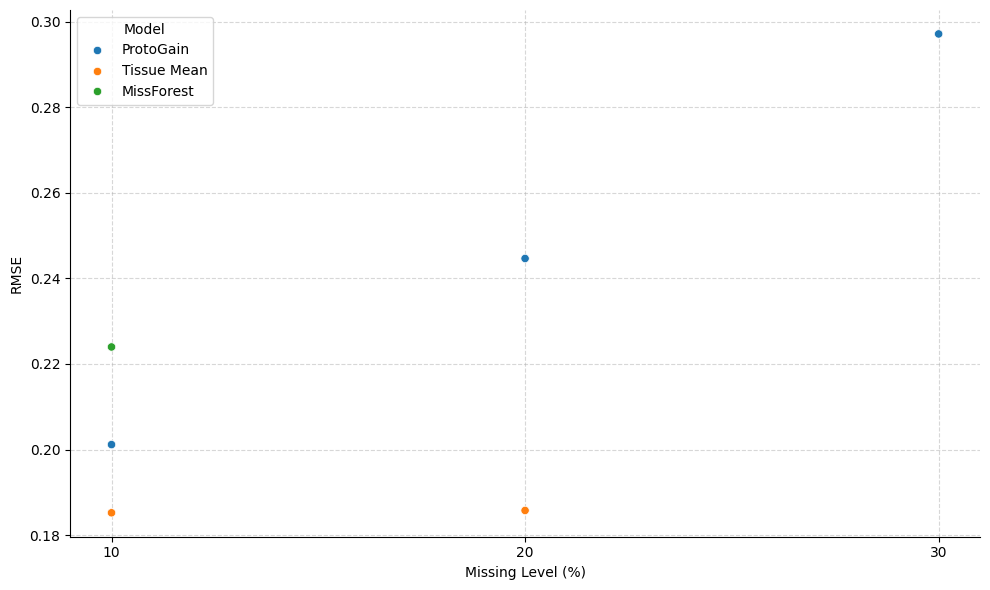

In [242]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=missing_performance,
    x="Miss level",
    y="RMSE",
    hue="Model",
    # marker="o",
    # linewidth=2,
    # markersize=8
)

plt.xlabel("Missing Level (%)")
plt.xticks(missing_performance["Miss level"].unique())
plt.ylabel("RMSE")
plt.grid(True, linestyle="--", alpha=0.5, zorder=0)
plt.legend(title="Model")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("./plots/holdout/rmse_vs_missing_level.png")
plt.show()